In [60]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [61]:
#transforma z intr-o valoare intre 0 si 1
def sigmoid(z):
        return 1 / (1 + np.exp(-z))

class MyRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def fit(self, x: list, y: list, learning_rate: float = 0.001, no_epochs: int = 1000):
        """Antrenează modelul de regresie logistică."""
        # Inițializează coeficienții aleatori
        self.coef_ = [random.random() for _ in range(len(x[0]) + 1)]
        
        # Aplică algoritmul gradient descent
        for _ in range(no_epochs):
            for i in range(len(x)):
                y_computed = sigmoid(self.eval(x[i], self.coef_))
                crt_error = y_computed - y[i]
                # Actualizează coeficienții
                for j in range(1, len(self.coef_)):
                    self.coef_[j] = self.coef_[j] - learning_rate * crt_error * x[i][j - 1]
                self.coef_[0] = self.coef_[0] - learning_rate * crt_error * 1

        # Salvează intercept-ul și coeficienții
        self.intercept_ = self.coef_[0]
        self.coef_ = self.coef_[1:]

    def eval(self, xi: list, coef: list):
        """Calculează valoarea estimată/suma ponderata+bias."""
        yi = coef[0]
        for j in range(len(xi)):
            yi += coef[j + 1] * xi[j]
        return yi

    def predict_one_sample(self, sample_features: list):
        """Predictia pentru un singur sample."""
        threshold = 0.5#prag de decizie
        coefficients = [self.intercept_] + [c for c in self.coef_]
        computed_float_value = self.eval(sample_features, coefficients)
        computed01_value = sigmoid(computed_float_value)
        computed_label = 0 if computed01_value < threshold else 1
        return computed_label

    def predict(self, in_test):
        """Predictia pentru un set de teste."""
        computed_labels = [self.predict_one_sample(sample) for sample in in_test]
        return computed_labels

In [62]:
def loadDataMoreInputs(fileName, inputVariabNames, outputVariabName):
    def transform_output(output):
        return 1 if output == 'M' else 0

    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabNames[0])
    selectedVariable2 = dataNames.index(inputVariabNames[1])
    inputs = [[float(data[i][selectedVariable1]), float(data[i][selectedVariable2])] for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [transform_output(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs, outputs

In [63]:
crtDir =  os.getcwd()
filePath = 'wdbc.csv'

inputs, outputs = loadDataMoreInputs(filePath, ['texture1', 'radius1'], 'Diagnosis')

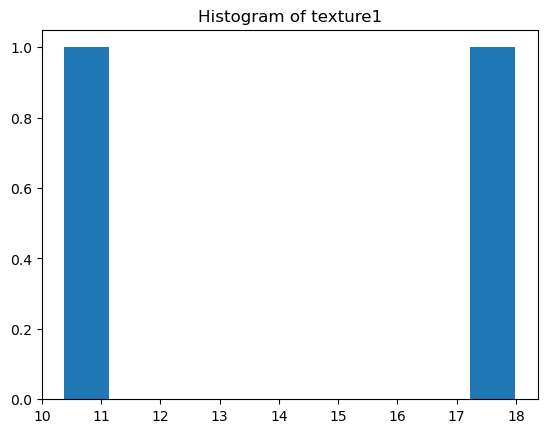

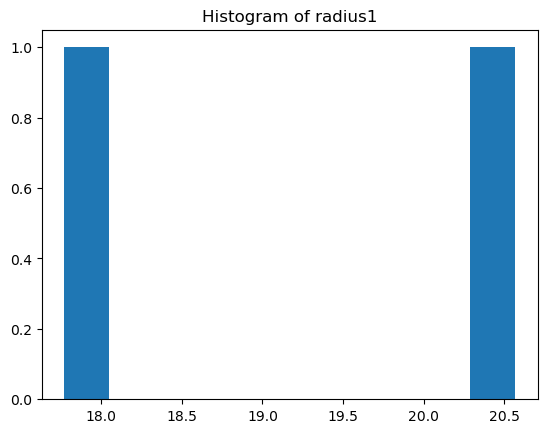

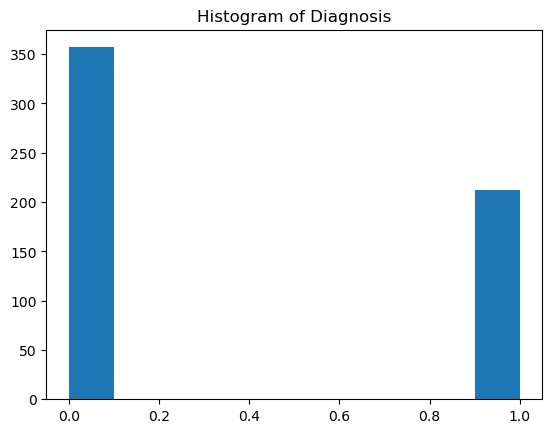

In [64]:
def plotHist(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotHist(inputs[0], "texture1")
plotHist(inputs[1], "radius1")

plotHist(outputs, 'Diagnosis')

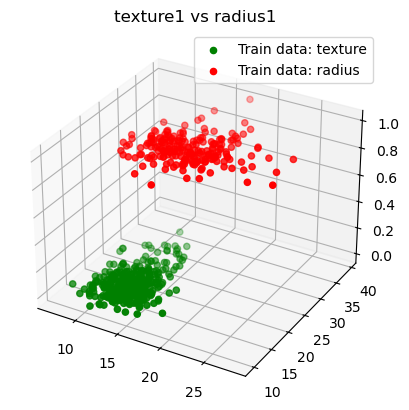

In [89]:
def plot3Ddata1(x1Train, x2Train, yTrain, x1Model=None, x2Model=None, yModel=None, x1Test=None, x2Test=None, yTest=None, title=None, classNames=None):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    ax = plt.axes(projection='3d')
    handles = []
    labels = []

    # Train data, cu nume de clasă din argument
    if x1Train is not None:
        classes = sorted(set(yTrain))
        color_map = {0: 'g', 1: 'r', 2: 'b'}
        for cls in classes:
            mask = [val == cls for val in yTrain]
            train_plot = ax.scatter(
                [x for x, m in zip(x1Train, mask) if m],
                [x for x, m in zip(x2Train, mask) if m],
                [x for x, m in zip(yTrain, mask) if m],
                c=color_map.get(cls, 'gray'),
                marker='o'
            )
            handles.append(train_plot)
            # Dacă există classNames și are destul elemente, îl folosim
            if classNames is not None and cls < len(classNames):
                labels.append(f'Train data: {classNames[cls]}')
            else:
                labels.append(f'Train data: clasa {cls}')

    # Model data
    if x1Model:
        model_plot = ax.scatter(x1Model, x2Model, yModel, c='pink', marker='o')
        handles.append(model_plot)
        labels.append('Learnt model')

    # Test data
    if x1Test :
        test_plot = ax.scatter(x1Test, x2Test, yTest, c='black', marker='^')
        handles.append(test_plot)
        labels.append('Test data')

    plt.title(title)

    if handles:
        ax.legend(handles, labels)

    plt.show()



plot3Ddata1(feature1, feature2, outputs, [], [], [], [], [], [], 'texture1 vs radius1',classNames=["texture","radius"])

In [66]:
def normalisation(train_data, test_data):
    train_data = [list(np.ravel(d)) for d in train_data]
    test_data = [list(np.ravel(d)) for d in test_data]
    scaler = StandardScaler()
    scaler.fit(train_data)
    normalisedTrainData = scaler.transform(train_data)
    normalisedTestData = scaler.transform(test_data)
    return normalisedTrainData, normalisedTestData


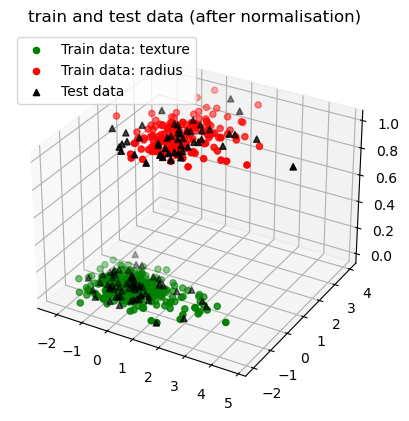

In [90]:
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]



trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]
trainInputs,testInputs=normalisation(trainInputs,testInputs)

feature1train = [ex[0] for ex in trainInputs]
feature2train = [ex[1] for ex in trainInputs]

feature1test = [ex[0] for ex in testInputs]
feature2test = [ex[1] for ex in testInputs]

plot3Ddata1(feature1train, feature2train, trainOutputs, None, None, None, feature1test, feature2test, testOutputs, "train and test data (after normalisation)",classNames=["texture","radius"])

In [91]:
model = MyRegression()
model.fit(trainInputs, trainOutputs)

# Evaluarea modelului personalizat pe datele de test
accuracy_custom = np.mean(model.predict(testInputs) == testOutputs)
print("Accuracy (Custom Logistic Regression):", accuracy_custom)

w0 = model.intercept_
w1, w2 = model.coef_
# Afișarea coeficienților și interceptării
print("Model coefficients (Custom Logistic Regression):")
print("f(x) =  1/ (1 + e^-z) where z = ", w0, ' + ', w1, ' * x1 + ', w2, ' * x2' )


Accuracy (Custom Logistic Regression): 0.0
Model coefficients (Custom Logistic Regression):
f(x) =  1/ (1 + e^-z) where z =  -0.9580041464238819  +  1.0410421688671168  * x1 +  4.447765777757952  * x2


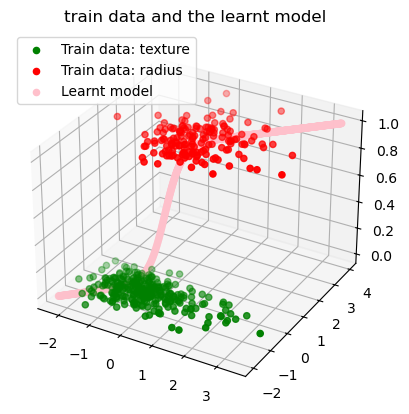

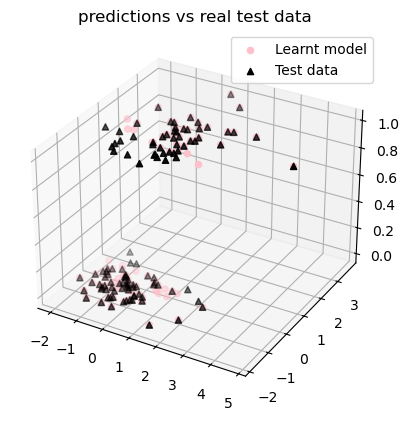

MyRegression
prediction error (manual):  0.19298245614035087


In [92]:
trainInputs = np.array(trainInputs)
noOfPoints = 1000
xref1 = []
val = min(trainInputs[:, 0])
step1 = (max(trainInputs[:, 0]) - min(trainInputs[:, 0])) / noOfPoints
for _ in range(noOfPoints):
    xref1.append(val)
    val += step1

xref2 = []
val = min(trainInputs[:, 1])
step2 = (max(trainInputs[:, 1]) - min(trainInputs[:, 1])) / noOfPoints
for _ in range(noOfPoints):
    xref2.append(val)
    val += step2

yref = [1 / (1 + np.exp(-(w0 + w1 * el1 + w2 * el2))) for el1, el2 in zip(xref1, xref2)]
plot3Ddata1(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model',classNames=["texture","radius"])

computedTestOutputs = model.predict(testInputs)

plot3Ddata1([], [], [], feature1test, feature2test, computedTestOutputs, feature1test, feature2test, testOutputs, 'predictions vs real test data',classNames=["texture","radius"])
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)


print("MyRegression")
print('prediction error (manual): ', error)

In [ ]:
CU TOOL

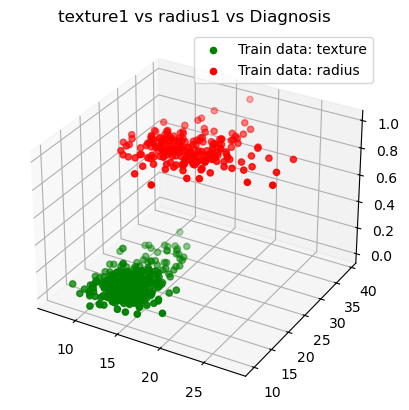

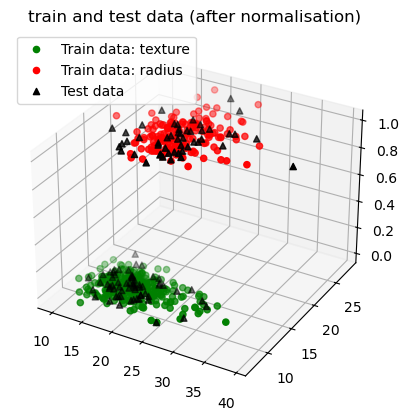

In [96]:
crtDir =  os.getcwd()
filePath = 'wdbc.csv'

inputs, outputs = loadDataMoreInputs(filePath, ['texture1', 'radius1'], 'Diagnosis')

plot3Ddata1(feature1, feature2, outputs, [], [], [], [], [], [], 'texture1 vs radius1 vs Diagnosis',classNames=["texture","radius"])

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]

trainInputs,testInputs=normalisation(trainInputs,testInputs)

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]


feature1train = [ex[0] for ex in trainInputs]
feature2train = [ex[1] for ex in trainInputs]

feature1test = [ex[0] for ex in testInputs]
feature2test = [ex[1] for ex in testInputs]

plot3Ddata1(feature1train, feature2train, trainOutputs, None, None, None, feature1test, feature2test, testOutputs, "train and test data (after normalisation)",classNames=["texture","radius"])



In [97]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt


model = LogisticRegression()
model.fit(trainInputs, trainOutputs)

accuracy = model.score(testInputs, testOutputs)
print("Accuracy:", accuracy)

#Coef
w1, w2 = model.coef_[0]
w0 = model.intercept_[0]

# Afișarea coeficienților și interceptării
print("Model coefficients:")
print("f(x) =  1/ 1+ e^-z.......z= ", w0, ' + ', w1, ' * x1 + ', w2, ' * x2' )

Accuracy: 0.8070175438596491
Model coefficients:
f(x) =  1/ 1+ e^-z.......z=  -23.204898336195647  +  0.2448107856254405  * x1 +  1.243674004866168  * x2


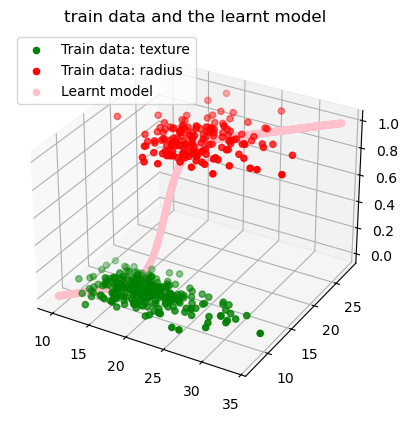

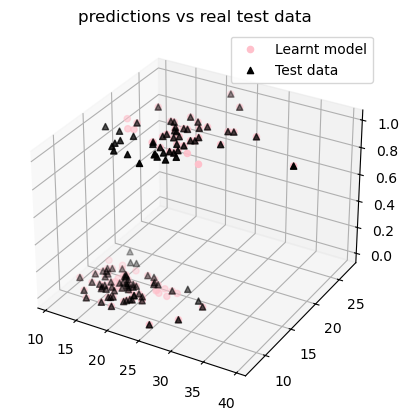

MyRegression
prediction error (manual):  0.19298245614035087
prediction error (tool):    0.19298245614035092


In [98]:
trainInputs = np.array(trainInputs)
noOfPoints = 1000
xref1 = []
val = min(trainInputs[:, 0])
step1 = (max(trainInputs[:, 0]) - min(trainInputs[:, 0])) / noOfPoints
for _ in range(noOfPoints):
    xref1.append(val)
    val += step1

xref2 = []
val = min(trainInputs[:, 1])
step2 = (max(trainInputs[:, 1]) - min(trainInputs[:, 1])) / noOfPoints
for _ in range(noOfPoints):
    xref2.append(val)
    val += step2

yref = [1 / (1 + np.exp(-(w0 + w1 * el1 + w2 * el2))) for el1, el2 in zip(xref1, xref2)]
plot3Ddata1(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model',classNames=["texture","radius"])

computedTestOutputs = model.predict(testInputs)

plot3Ddata1([], [], [], feature1test, feature2test, computedTestOutputs, feature1test, feature2test, testOutputs, 'predictions vs real test data',classNames=["texture","radius"])
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)


print("MyRegression")
print('prediction error (manual): ', error)
error = 1 - accuracy

print('prediction error (tool):   ', error)

In [99]:
ec = 1 / (1 + np.exp(-(w0 + w1 * 10 + w2 * 18)))
print("Rez ec", ec)
if ec >= 0.5:
    print("Malign")
else:
    print("Benign ")

Rez ec 0.8360794256619797
Malign
